General plant data Imported from Kaggle. Dataset will be used to train a machine learning algorithm that will be used for a plant monitoring project.

Import Libraries

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import math

from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [111]:
df = pd.read_csv('plant_health_data.csv')

### EDA and Preprocessing

In [112]:
df.head()

,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [113]:
print("shape of the dataset:", df.shape)


shape of the dataset: (1200, 14)


In [114]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               1200 non-null   object 
 1   Plant_ID                1200 non-null   int64  
 2   Soil_Moisture           1200 non-null   float64
 3   Ambient_Temperature     1200 non-null   float64
 4   Soil_Temperature        1200 non-null   float64
 5   Humidity                1200 non-null   float64
 6   Light_Intensity         1200 non-null   float64
 7   Soil_pH                 1200 non-null   float64
 8   Nitrogen_Level          1200 non-null   float64
 9   Phosphorus_Level        1200 non-null   float64
 10  Potassium_Level         1200 non-null   float64
 11  Chlorophyll_Content     1200 non-null   float64
 12  Electrochemical_Signal  1200 non-null   float64
 13  Plant_Health_Status     1200 non-null   object 
dtypes: float64(11), int64(1), object(2)
memo

In [115]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Plant_ID,1200.0,5.500000,2.873479,1.000000,3.000000,5.500000,8.000000,10.000000
Soil_Moisture,1200.0,25.106918,8.677725,10.000724,17.131893,25.168333,32.370231,39.993164
Ambient_Temperature,1200.0,23.999130,3.441561,18.001993,21.101766,23.889044,27.042634,29.990886
Soil_Temperature,1200.0,19.957794,2.932073,15.003710,17.353027,19.911473,22.596851,24.995929
Humidity,1200.0,54.853165,8.784916,40.028758,47.019694,54.692069,62.451053,69.968871
Light_Intensity,1200.0,612.637265,228.318853,200.615482,416.878983,617.240221,811.474690,999.856262
Soil_pH,1200.0,6.524102,0.581755,5.507392,6.026042,6.540524,7.030039,7.497823
Nitrogen_Level,1200.0,30.106751,11.514396,10.003650,20.249774,30.138590,40.184737,49.951136
Phosphorus_Level,1200.0,30.264484,11.466846,10.017690,20.894445,30.019385,40.131459,49.980700
Potassium_Level,1200.0,30.112088,11.668085,10.000606,19.585561,30.495054,40.108296,49.981945


In [116]:
df.dtypes


Timestamp                  object
Plant_ID                    int64
Soil_Moisture             float64
Ambient_Temperature       float64
Soil_Temperature          float64
Humidity                  float64
Light_Intensity           float64
Soil_pH                   float64
Nitrogen_Level            float64
Phosphorus_Level          float64
Potassium_Level           float64
Chlorophyll_Content       float64
Electrochemical_Signal    float64
Plant_Health_Status        object
dtype: object

In [117]:
df.count()


Timestamp                 1200
Plant_ID                  1200
Soil_Moisture             1200
Ambient_Temperature       1200
Soil_Temperature          1200
Humidity                  1200
Light_Intensity           1200
Soil_pH                   1200
Nitrogen_Level            1200
Phosphorus_Level          1200
Potassium_Level           1200
Chlorophyll_Content       1200
Electrochemical_Signal    1200
Plant_Health_Status       1200
dtype: int64

#### Looking at null values

In [118]:
df.isnull().sum()


Timestamp                 0
Plant_ID                  0
Soil_Moisture             0
Ambient_Temperature       0
Soil_Temperature          0
Humidity                  0
Light_Intensity           0
Soil_pH                   0
Nitrogen_Level            0
Phosphorus_Level          0
Potassium_Level           0
Chlorophyll_Content       0
Electrochemical_Signal    0
Plant_Health_Status       0
dtype: int64

In [119]:
print(df.nunique())


Timestamp                 1200
Plant_ID                    10
Soil_Moisture             1200
Ambient_Temperature       1200
Soil_Temperature          1200
Humidity                  1200
Light_Intensity           1200
Soil_pH                   1200
Nitrogen_Level            1200
Phosphorus_Level          1200
Potassium_Level           1200
Chlorophyll_Content       1200
Electrochemical_Signal    1200
Plant_Health_Status          3
dtype: int64


In [120]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print(numerical_columns)
print(categorical_columns)

['Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal']
['Timestamp', 'Plant_Health_Status']


#### Distribution

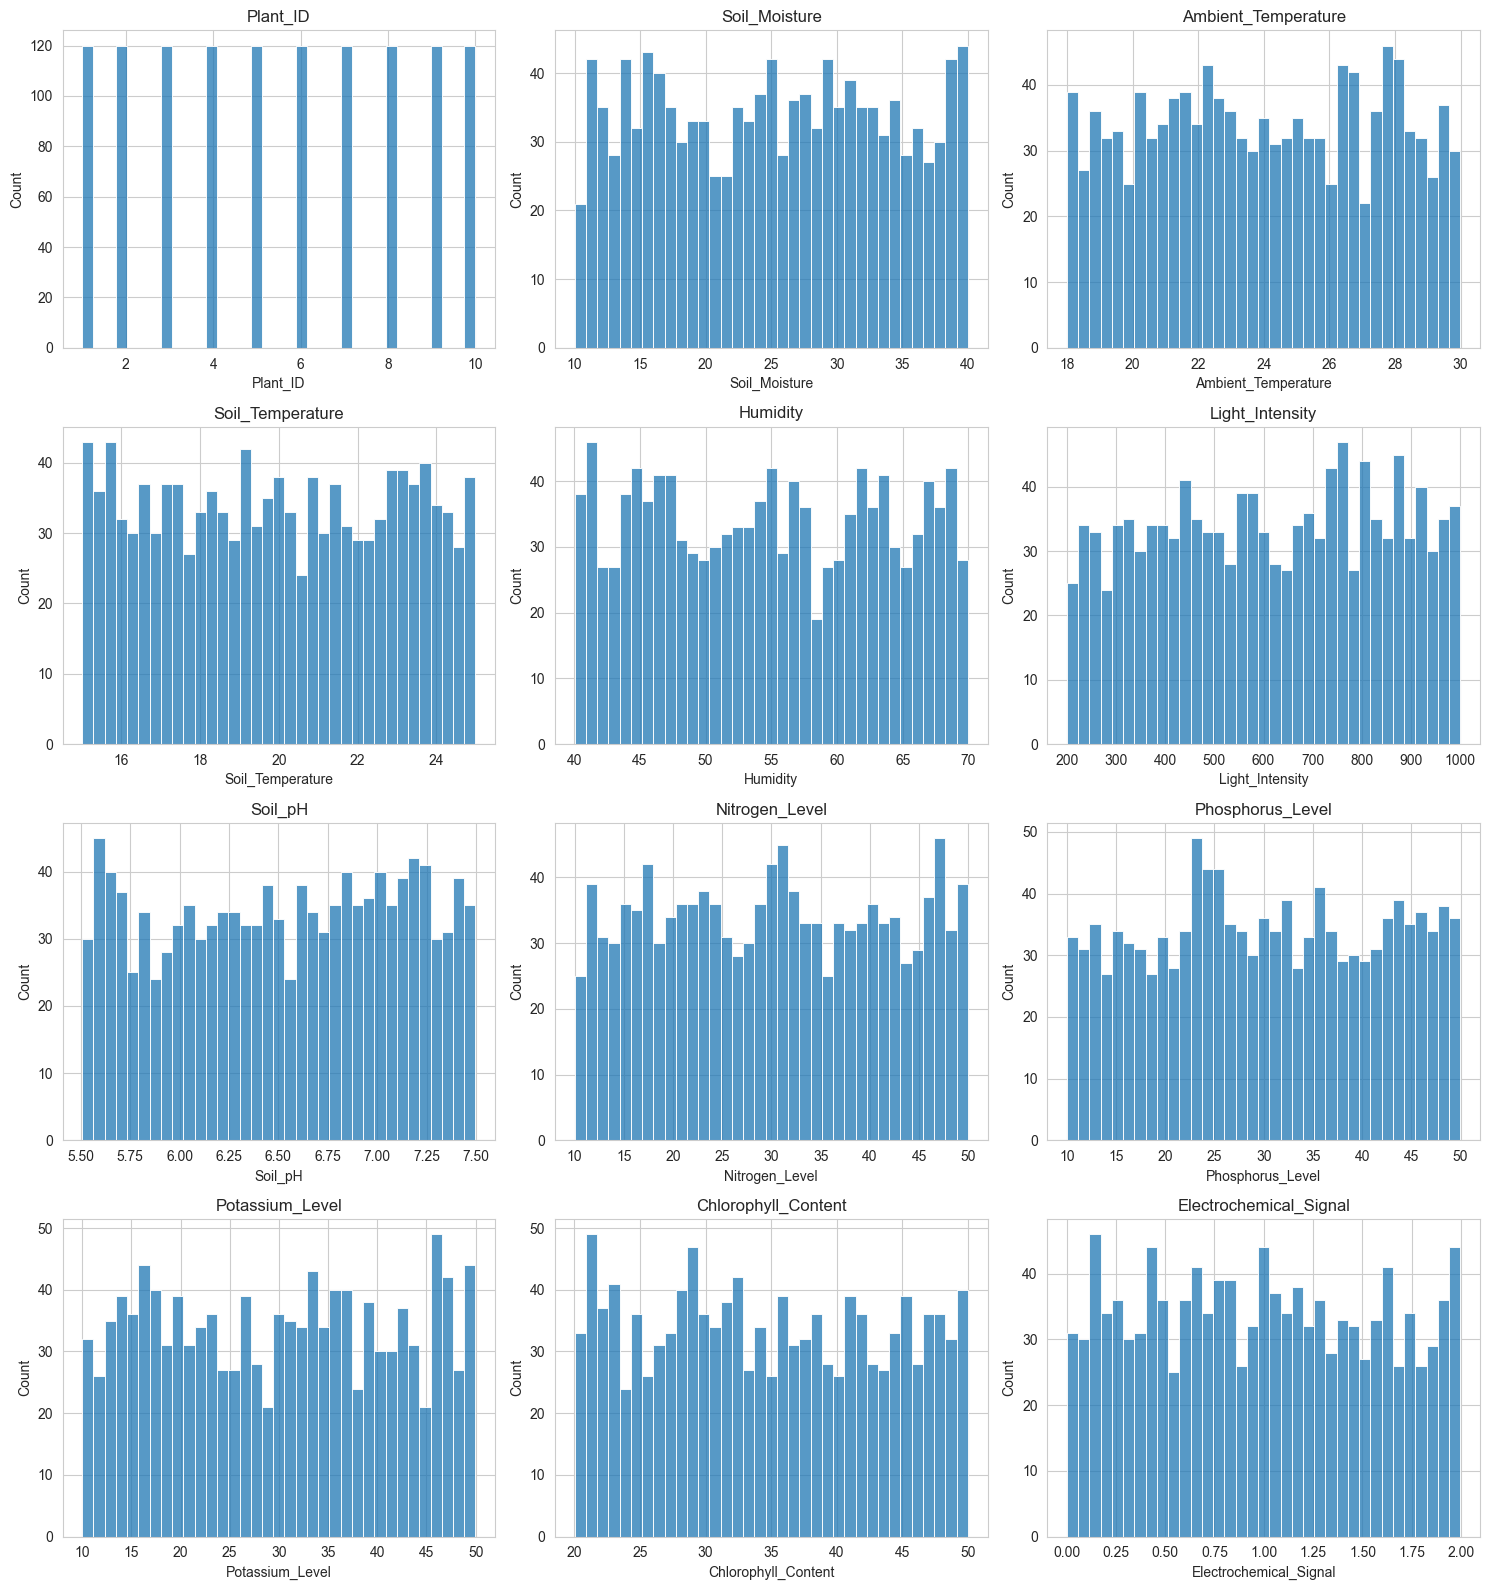

In [121]:
n_cols = len(numerical_columns)

# Define grid dimensions (3 columns wide)
grid_cols = 3
grid_rows = math.ceil(n_cols / grid_cols)

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(15, grid_rows * 4))
axes = axes.flatten()  # Flatten into 1D array for easy looping

# Loop through columns and axes simultaneously
for i, col in enumerate(numerical_columns):
    sns.histplot(data=df, x=col, ax=axes[i], bins = 35)
    axes[i].set_title(col)

# Hide any empty subplot boxes at the end of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # Fixes overlapping labels
plt.show()

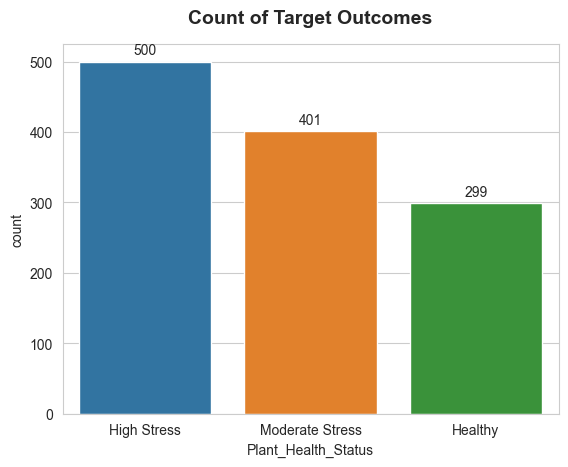

In [122]:
target_column = 'Plant_Health_Status'


ax = sns.countplot(
    data=df, 
    x=target_column, 
    order=df[target_column].value_counts().index,
    hue=target_column,          # Gives each unique category its own color
    legend=False          # Removes the redundant legend since x-axis has labels
)

ax.set_title("Count of Target Outcomes", fontsize=14, fontweight="bold", pad=15)
             
for container in ax.containers:
    ax.bar_label(container, padding=3)  # Adds a small spacing gap above the bar

plt.show()


C:\Users\salja\AppData\Local\Temp\ipykernel_53264\2377718036.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\salja\AppData\Local\Temp\ipykernel_53264\2377718036.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\salja\AppData\Local\Temp\ipykernel_53264\2377718036.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\salja\AppData\Local\Temp\ipykernel_53264\2377718036.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

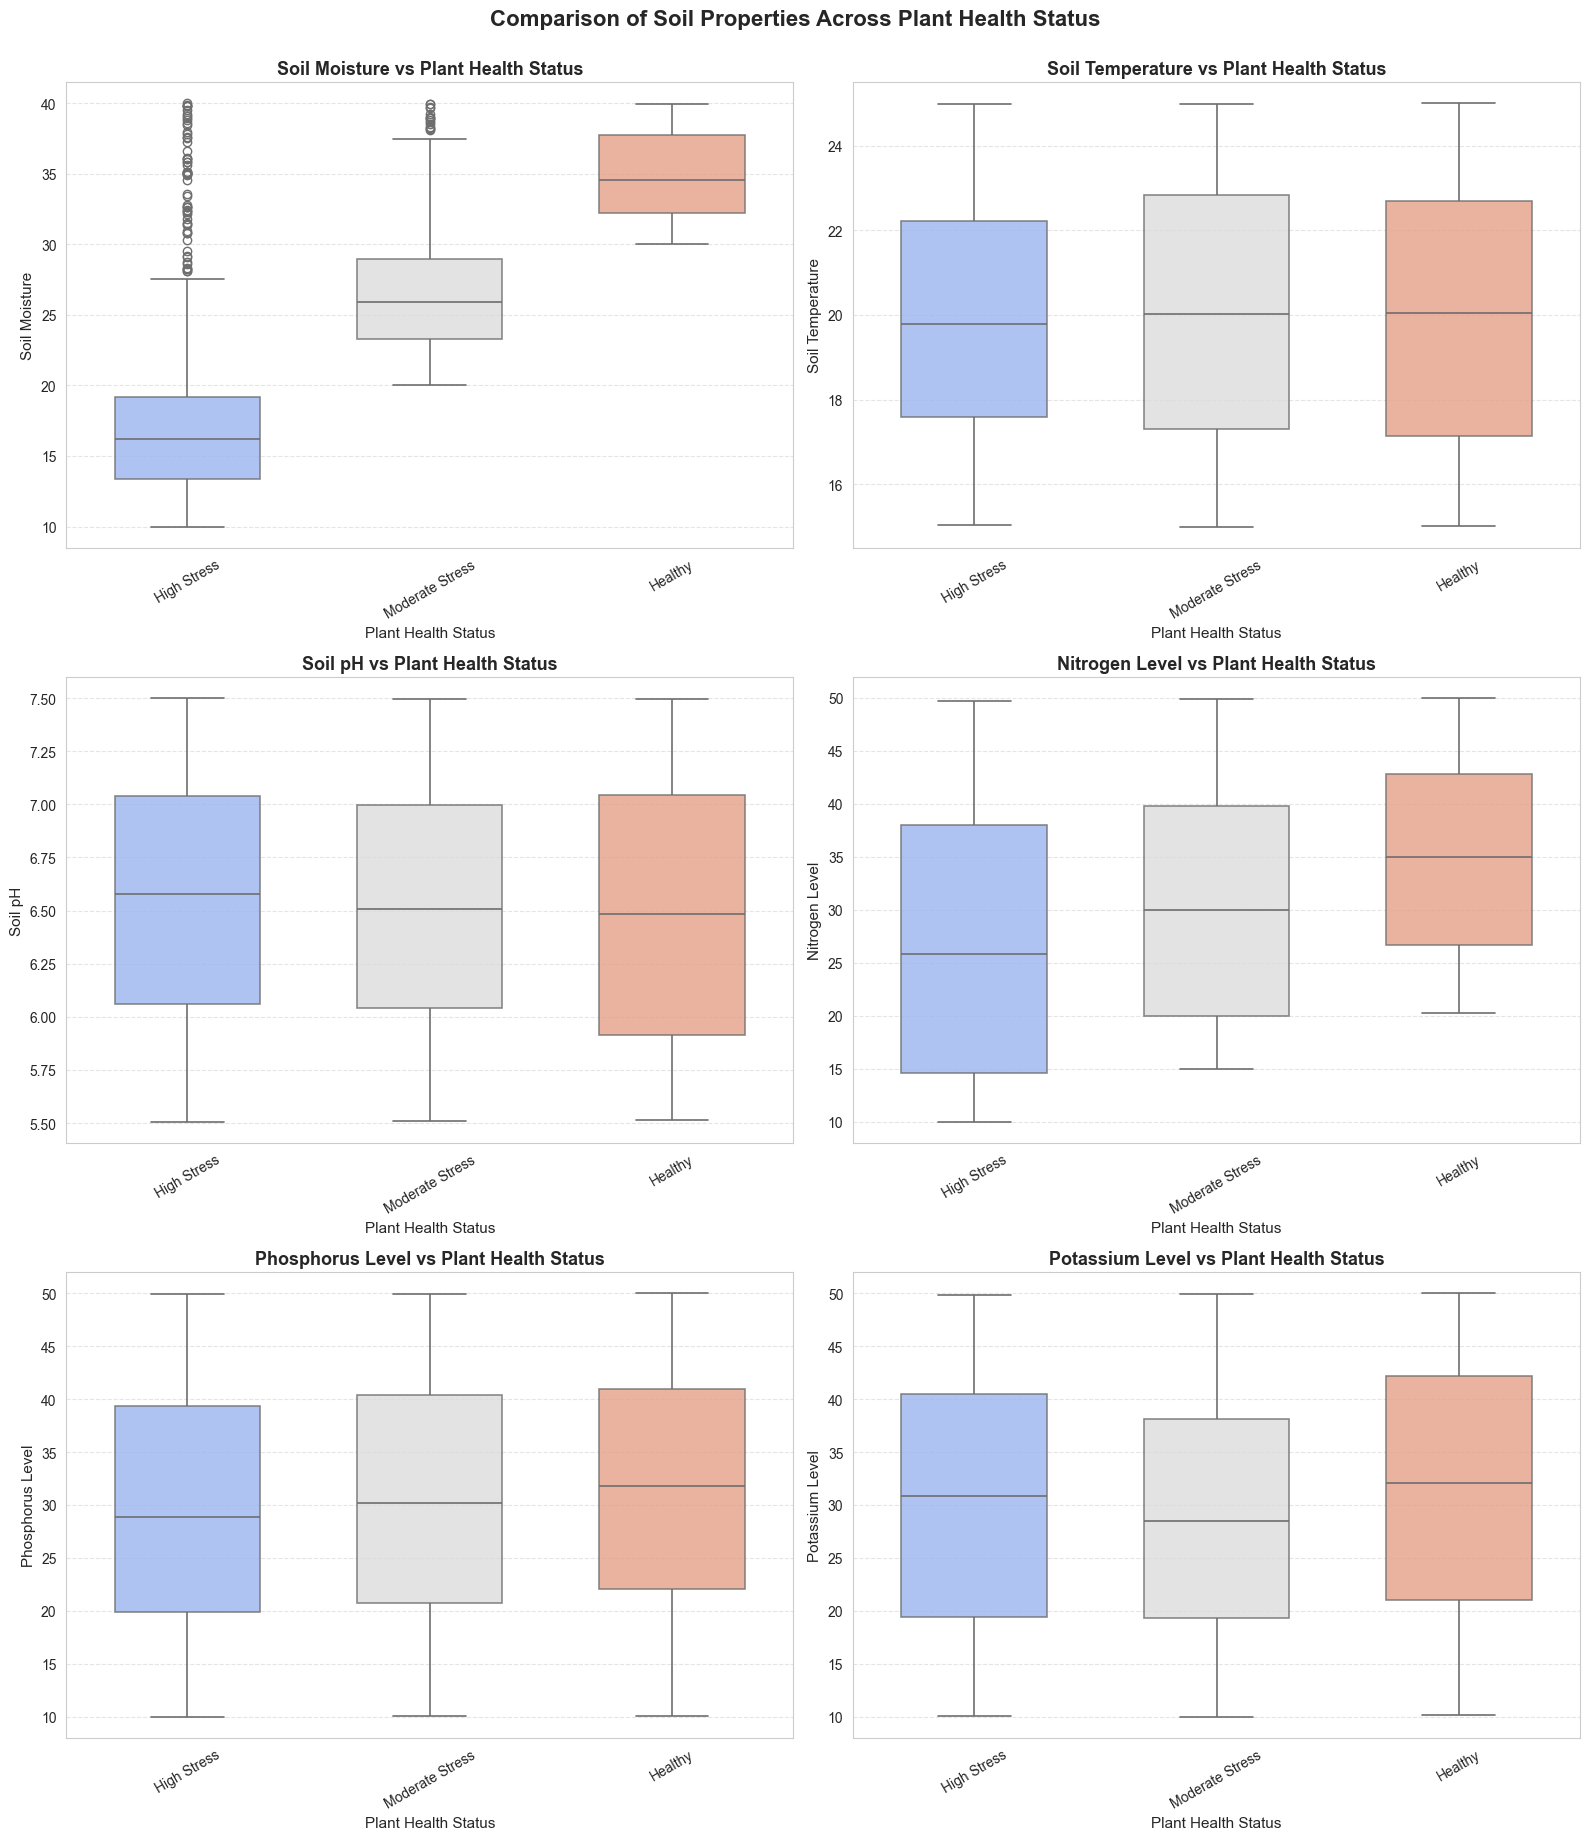

In [123]:

# Define soil properties
soil_properties = [
    'Soil_Moisture', 'Soil_Temperature', 'Soil_pH', 
    'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level'
]

# Visualization setup
sns.set_style("whitegrid")
plt.figure(figsize=(16, 18))

# Create subplots to visualize relationships
for i, feature in enumerate(soil_properties):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(
        x='Plant_Health_Status',
        y=feature,
        data=df,
        palette='coolwarm',
        linewidth=1.2,
        width=0.6,
        boxprops=dict(alpha=0.8)
    )
    plt.title(f'{feature.replace("_", " ")} vs Plant Health Status', fontsize=13, fontweight='bold')
    plt.xlabel('Plant Health Status', fontsize=11)
    plt.ylabel(feature.replace('_', ' '), fontsize=11)
    plt.xticks(rotation=30)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('Comparison of Soil Properties Across Plant Health Status', fontsize=16, fontweight='bold', y=1.02)
plt.show()

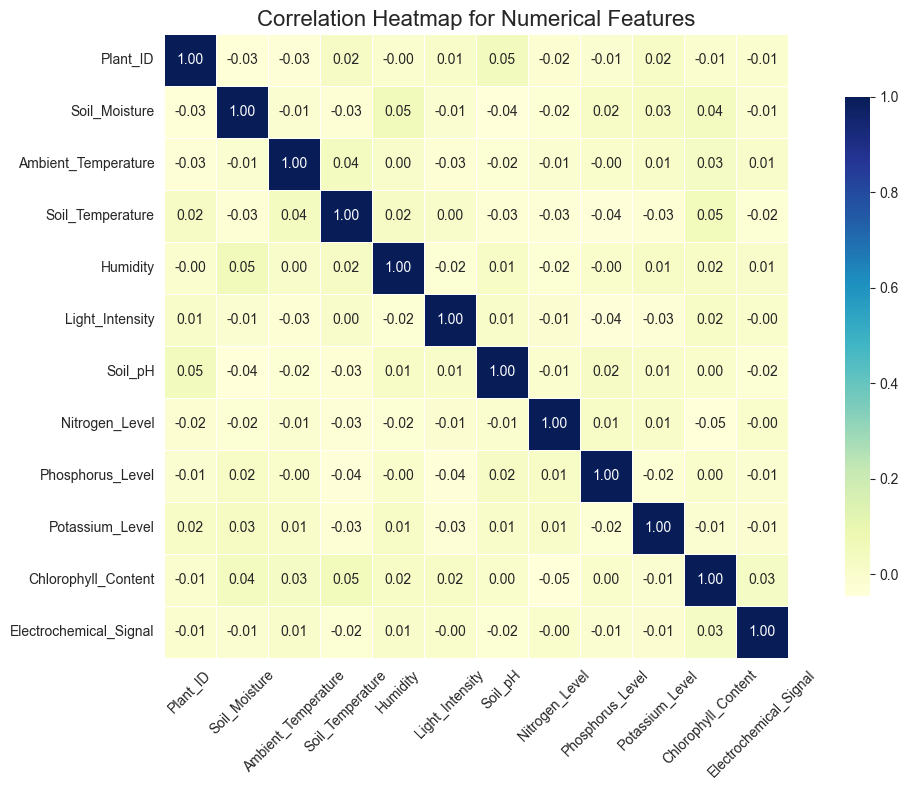

In [124]:
numerical_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='YlGnBu', 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap for Numerical Features', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [125]:
custom_mapping = {'High Stress': 2, 'Moderate Stress': 1, 'Healthy': 0}
df['Plant_Health_Status_Encoded'] = df['Plant_Health_Status'].map(custom_mapping)


In [126]:
df = df.drop(columns=['Plant_Health_Status'])

In [127]:
df = df.drop(columns = ['Timestamp', "Plant_ID"])

A dataframe with less features.

In [128]:
df_reduced = df.loc[:,['Ambient_Temperature', 'Soil_Moisture','Light_Intensity',"Humidity","Plant_Health_Status_Encoded"]]
df_reduced.head()

,Ambient_Temperature,Soil_Moisture,Light_Intensity,Humidity,Plant_Health_Status_Encoded
0,22.240245,27.521109,556.172805,55.291904,2
1,21.706763,14.835566,596.136721,63.949181,2
2,21.180946,17.086362,591.124627,67.837956,2
3,22.593302,15.336156,241.412476,58.190811,2
4,28.929001,39.822216,444.493830,63.772036,2


In [129]:
# Define features and target
X = df.drop(columns=['Plant_Health_Status_Encoded'])  # Features
y = df['Plant_Health_Status_Encoded']  # Target

In [130]:
X_red = df_reduced.drop(columns=['Plant_Health_Status_Encoded'])
y_red = df_reduced['Plant_Health_Status_Encoded']

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [132]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(X_red, y_red, test_size=0.2, random_state=42, stratify=y)

In [133]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Display model names to confirm initialization
print("Models initialized:", list(models.keys()))

Models initialized: ['Decision Tree', 'Random Forest', 'Gradient Boosting']


Starting model training and evaluation...


------------------
Decision Tree
Accuracy: 0.992
AUC: 0.993
------------------


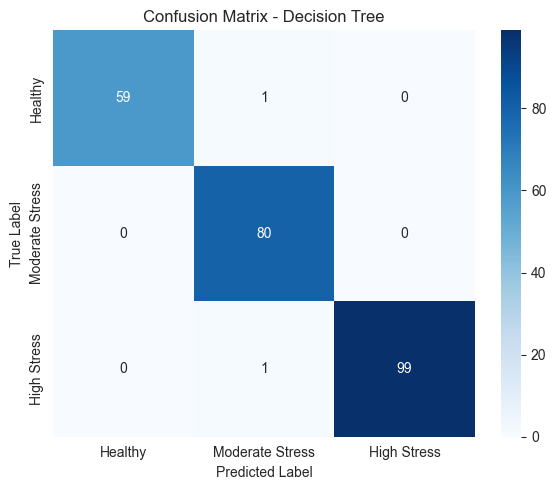


Classification Report:

                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      1.00      0.99        80
    High Stress       1.00      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240


------------------
Random Forest
Accuracy: 0.988
AUC: 1.000
------------------


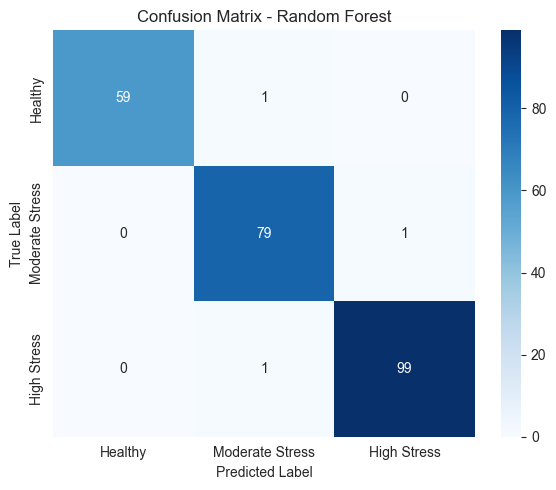


Classification Report:

                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240


------------------
Gradient Boosting
Accuracy: 0.988
AUC: 0.994
------------------


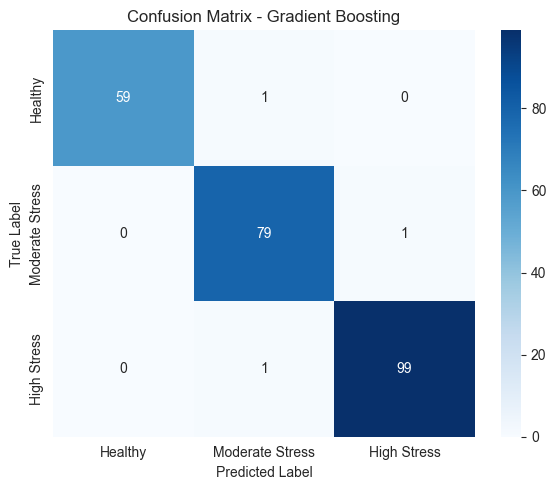


Classification Report:

                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
Moderate Stress       0.98      0.99      0.98        80
    High Stress       0.99      0.99      0.99       100

       accuracy                           0.99       240
      macro avg       0.99      0.99      0.99       240
   weighted avg       0.99      0.99      0.99       240


Overall Model Performance Summary



,Model,Accuracy,AUC,Healthy F1,Moderate Stress F1,High Stress F1,Macro Avg F1,Weighted Avg F1
0,Decision Tree,0.992,0.993,0.992,0.988,0.995,0.991,0.992
1,Random Forest,0.988,1.000,0.992,0.981,0.990,0.988,0.988
2,Gradient Boosting,0.988,0.994,0.992,0.981,0.990,0.988,0.988


In [134]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

class_labels = ["Healthy", "Moderate Stress", "High Stress"]

model_scores = []

print("Starting model training and evaluation...\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    try:
        y_prob = model.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
    except Exception:
        auc = np.nan

    report = classification_report(
        y_test,
        y_pred,
        target_names=class_labels,
        output_dict=True
    )

    model_scores.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Healthy F1": report["Healthy"]["f1-score"],
        "Moderate Stress F1": report["Moderate Stress"]["f1-score"],
        "High Stress F1": report["High Stress"]["f1-score"],
        "Macro Avg F1": report["macro avg"]["f1-score"],
        "Weighted Avg F1": report["weighted avg"]["f1-score"]
    })

    print("\n" + "------------------")
    print(f"{name}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"AUC: {auc:.3f}" if not np.isnan(auc) else "AUC: Not available")
    print("------------------")

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=class_labels))


results_df = pd.DataFrame(model_scores)

summary_table = (
    results_df
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nOverall Model Performance Summary\n")
display(summary_table.round(3))

Starting model training and evaluation...


------------------
Decision Tree
Accuracy: 0.754
AUC: 0.817
------------------


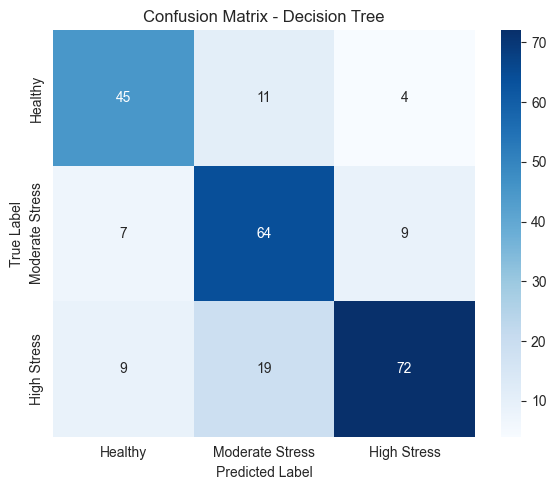


Classification Report:

                 precision    recall  f1-score   support

        Healthy       0.74      0.75      0.74        60
Moderate Stress       0.68      0.80      0.74        80
    High Stress       0.85      0.72      0.78       100

       accuracy                           0.75       240
      macro avg       0.76      0.76      0.75       240
   weighted avg       0.76      0.75      0.76       240


------------------
Random Forest
Accuracy: 0.842
AUC: 0.905
------------------


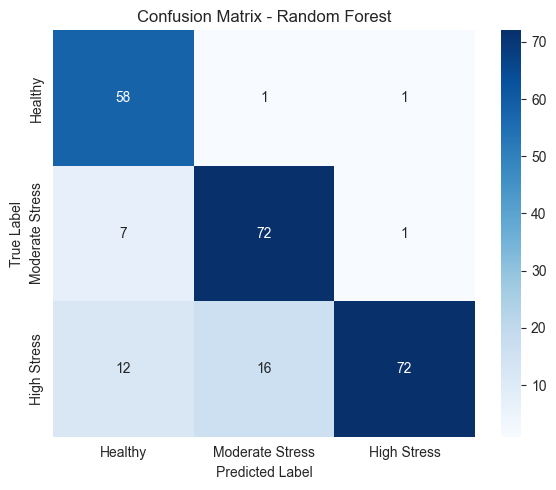


Classification Report:

                 precision    recall  f1-score   support

        Healthy       0.75      0.97      0.85        60
Moderate Stress       0.81      0.90      0.85        80
    High Stress       0.97      0.72      0.83       100

       accuracy                           0.84       240
      macro avg       0.85      0.86      0.84       240
   weighted avg       0.86      0.84      0.84       240


------------------
Gradient Boosting
Accuracy: 0.838
AUC: 0.896
------------------


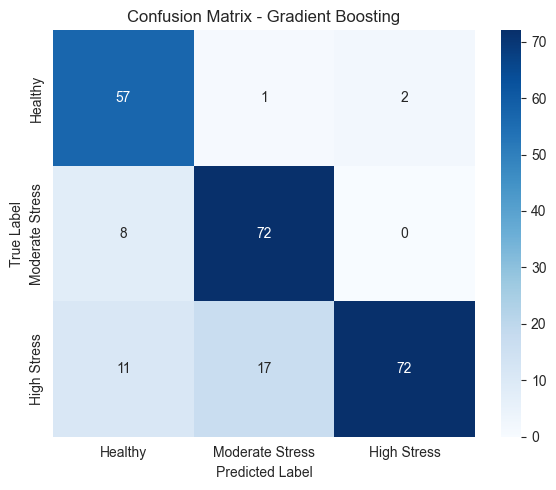


Classification Report:

                 precision    recall  f1-score   support

        Healthy       0.75      0.95      0.84        60
Moderate Stress       0.80      0.90      0.85        80
    High Stress       0.97      0.72      0.83       100

       accuracy                           0.84       240
      macro avg       0.84      0.86      0.84       240
   weighted avg       0.86      0.84      0.84       240


Overall Model Performance Summary



,Model,Accuracy,AUC,Healthy F1,Moderate Stress F1,High Stress F1,Macro Avg F1,Weighted Avg F1
0,Random Forest,0.842,0.905,0.847,0.852,0.828,0.842,0.841
1,Gradient Boosting,0.838,0.896,0.838,0.847,0.828,0.838,0.837
2,Decision Tree,0.754,0.817,0.744,0.736,0.778,0.753,0.755


In [135]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

class_labels = ["Healthy", "Moderate Stress", "High Stress"]

model_scores = []

print("Starting model training and evaluation...\n")

for name, model in models.items():

    model.fit(X_train_red, y_train_red)

    y_pred_red = model.predict(X_test_red)

    accuracy = accuracy_score(y_test_red, y_pred_red)

    try:
        y_prob_red = model.predict_proba(X_test_red)
        auc = roc_auc_score(y_test_red, y_prob_red, multi_class="ovr")
    except Exception:
        auc = np.nan

    report = classification_report(
        y_test_red,
        y_pred_red,
        target_names=class_labels,
        output_dict=True
    )

    model_scores.append({
        "Model": name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Healthy F1": report["Healthy"]["f1-score"],
        "Moderate Stress F1": report["Moderate Stress"]["f1-score"],
        "High Stress F1": report["High Stress"]["f1-score"],
        "Macro Avg F1": report["macro avg"]["f1-score"],
        "Weighted Avg F1": report["weighted avg"]["f1-score"]
    })

    print("\n" + "------------------")
    print(f"{name}")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"AUC: {auc:.3f}" if not np.isnan(auc) else "AUC: Not available")
    print("------------------")

    cm = confusion_matrix(y_test_red, y_pred_red)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_test_red, y_pred_red, target_names=class_labels))


results_df = pd.DataFrame(model_scores)

summary_table = (
    results_df
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nOverall Model Performance Summary\n")
display(summary_table.round(3))